In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/WineQT.csv')

## Пояснение к Данным
    1. fixed acidity (связанная/фиксированная кислотность) — количество основных кислот вина (в основном винной). Они не испаряются и отвечают за общую структуру вкуса. Если их слишком мало, вино кажется плоским и пресным.
    2. volatile acidity (летучая кислотность) — количество уксусной кислоты. Если её много, вино начинает неприятно пахнуть уксусом. Главный вредитель: обычно имеет сильную отрицательную корреляцию с качеством (чем её больше, тем хуже оценка).
    3. citric acid (лимонная кислота) — присутствует в вине в небольших количествах. Она добавляет вкусу «свежести» и фруктовых ноток.
    4. residual sugar (остаточный сахар) — сахар, который остался в вине после завершения процесса брожения. Помогает понять, насколько вино сухое или сладкое.
    5. chlorides (хлориды) — количество соли в вине. Влияет на минеральность вкуса, но избыток соли делает вино грубым.
    6. free sulfur dioxide (свободный диоксид серы / сернистый газ) — защищает вино от окисления на воздухе и не дает размножаться вредным микробам.
    7. total sulfur dioxide (общий диоксид серы) — суммарный объем сернистого газа. Важный момент: если винодел переборщил с серой, у вина будет резкий химический запах, а у того, кто его выпьет, наутро будет сильно болеть голова.
    8. density (плотность) — плотность напитка. Она напрямую зависит от баланса: сахар делает вино более плотным, а алкоголь — более легким.
    9. pH (водородный показатель) — описывает, насколько вино кислое по шкале от 0 (чистая кислота) до 14 (щелочь). Большинство вин очень кислые и укладываются в узкий диапазон от 3.0 до 4.0.
    10. sulphates (сульфаты) — винная добавка, которая работает как антиоксидант и антибиотик, помогая вину сохранять свежесть и защищая его свойства.
    11. alcohol (алкоголь) — крепость вина (процент содержания спирта). Главный любимец сомелье: как правило, вина с чуть более высоким градусом (в разумных пределах) получают более высокие оценки за богатый вкус.

    Переменную которую надо предсказать: quality (качество вина)

## ВСЯ РАБОТА

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df = df.drop('Id', axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


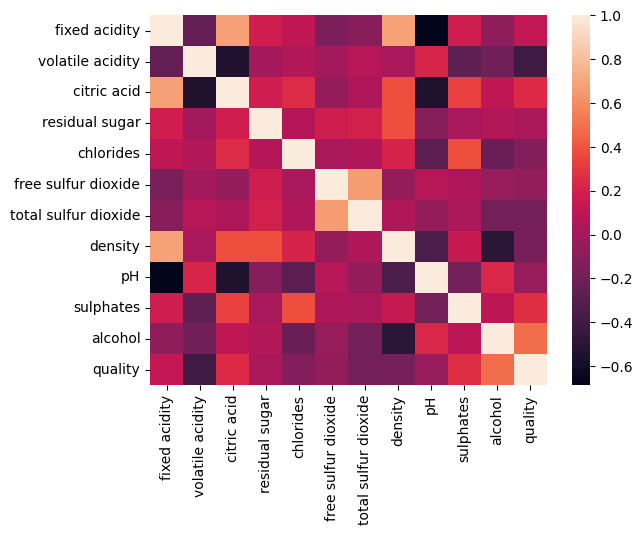

In [7]:
sns.heatmap(df.corr());

<Axes: xlabel='quality', ylabel='alcohol'>

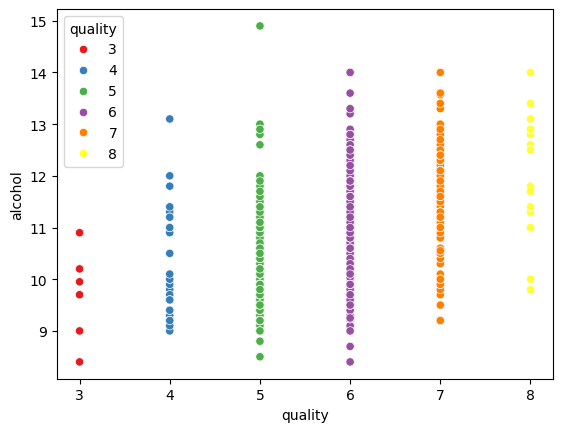

In [8]:
sns.scatterplot(x='quality', y='alcohol', data=df, hue='quality', palette='Set1')

In [9]:
df[df['alcohol'] > 14.8]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
462,15.9,0.36,0.65,7.5,0.096,22.0,71.0,0.9976,2.98,0.84,14.9,5


In [10]:
df = df.drop(462)

<Axes: xlabel='quality', ylabel='volatile acidity'>

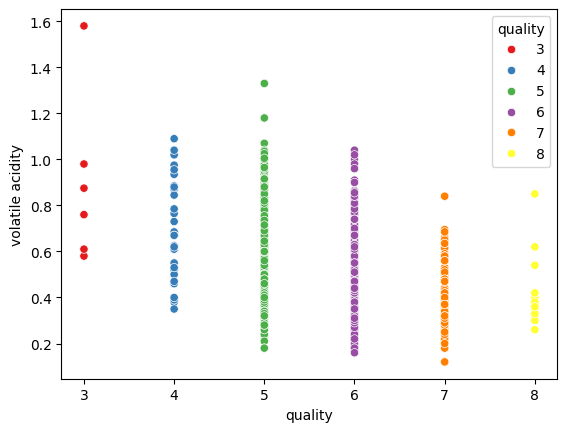

In [11]:
sns.scatterplot(x='quality', y='volatile acidity', data=df, hue='quality', palette='Set1')

In [12]:
df[df['volatile acidity'] > 1.5]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
922,7.6,1.58,0.0,2.1,0.137,5.0,9.0,0.99476,3.5,0.4,10.9,3


In [13]:
df[(df['quality'] == 5) & (df['volatile acidity'] > 1.3)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
87,8.2,1.33,0.0,1.7,0.081,3.0,12.0,0.9964,3.53,0.49,10.9,5
88,8.1,1.33,0.0,1.8,0.082,3.0,12.0,0.9964,3.54,0.48,10.9,5


In [14]:
df = df.drop([922, 87, 88])

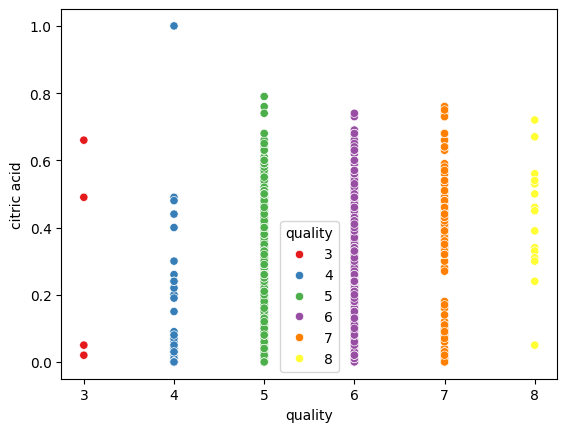

In [15]:
sns.scatterplot(x='quality', y='citric acid', data=df, hue='quality', palette='Set1');

In [16]:
df[df['citric acid']>0.9]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
103,9.2,0.52,1.0,3.4,0.61,32.0,69.0,0.9996,2.74,2.0,9.4,4


In [17]:
df = df.drop(103)

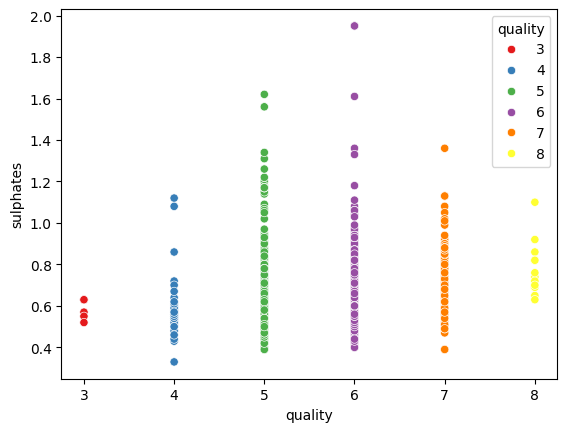

In [18]:
sns.scatterplot(x='quality', y='sulphates', data=df, hue='quality', palette='Set1');

In [19]:
df[df['sulphates'] > 1.9]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
59,8.6,0.49,0.28,1.9,0.11,20.0,136.0,0.9972,2.93,1.95,9.9,6
64,8.6,0.49,0.28,1.9,0.11,20.0,136.0,0.9972,2.93,1.95,9.9,6


In [20]:
df[(df['quality'] == 5) & (df['sulphates'] > 1.5)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
11,7.8,0.61,0.29,1.6,0.114,9.0,29.0,0.9974,3.26,1.56,9.1,5
514,7.1,0.31,0.30,2.2,0.053,36.0,127.0,0.9965,2.94,1.62,9.5,5


In [21]:
df = df.drop([59, 64, 11, 514])

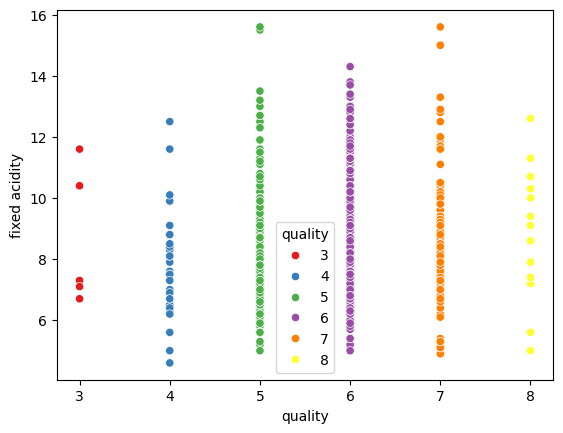

In [22]:
sns.scatterplot(x='quality', y='fixed acidity', data=df, hue='quality', palette='Set1');

In [23]:
df[(df['quality'] == 5) & (df['fixed acidity'] > 15)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
397,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5
399,15.6,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5


In [24]:
df = df.drop([397, 399])

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

In [26]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [27]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()

In [28]:
num_features

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [29]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler_2', StandardScaler()),
    ('model', ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7,.9, .95, .99, 1.0]))
])

In [30]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [31]:
best_model = pipe.named_steps['model']

print(f'Best alpha: {best_model.alpha_}')
print(f'Best l1_ratio: {best_model.l1_ratio_}')

Best alpha: 0.019663715181420485
Best l1_ratio: 1.0


In [32]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [33]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)

In [34]:
MAE

0.5180582190039954

In [35]:
MSE

0.45054558364429786

In [36]:
RMSE

np.float64(0.6712269241056246)

In [37]:
r2_train

0.4142160398791961

In [38]:
r2_test

0.37100758351688756

In [39]:
df['quality'].mean()

np.float64(5.6643109540636045)

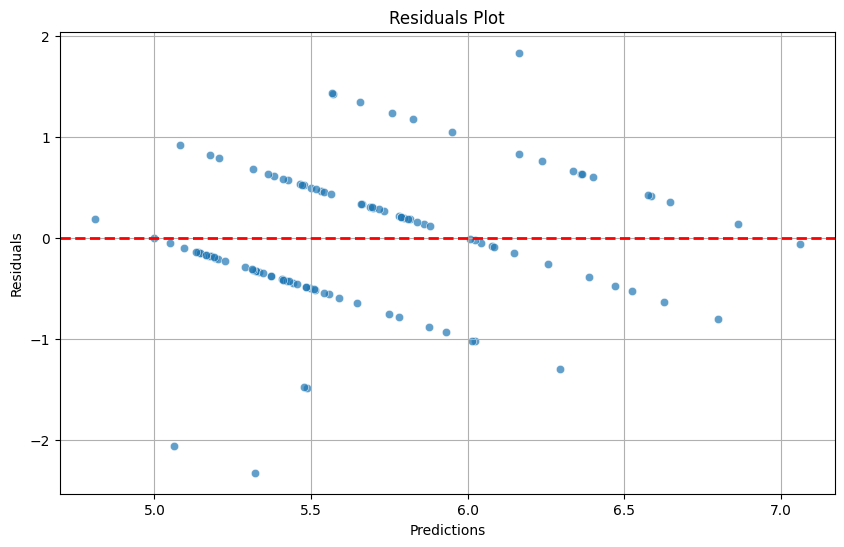

In [40]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

In [41]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [42]:
y_pred_full = pipe.predict(X)

In [43]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.024454552050424815
Лучшее значение l1_ratio: 1.0


In [44]:
r2_full = r2_score(y, y_pred_full)

In [45]:
r2_full

0.4047782254968908

In [46]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [47]:
wines = {
    'fixed acidity': [7.5, 8.5],
    'volatile acidity': [1.1, 0.28],
    'citric acid': [0.0, 0.4],
    'residual sugar': [1.9, 2.3],
    'chlorides': [0.076, 0.075],
    'free sulfur dioxide': [5.0, 12.0],
    'total sulfur dioxide': [15.0, 35.0],
    'density': [0.9978, 0.9940],
    'pH': [3.51, 3.26],
    'sulphates': [0.4, 0.85],
    'alcohol': [9.2, 13.2]
}

In [48]:
wines_df = pd.DataFrame(wines)

In [49]:
wines_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.5,1.10,0.0,1.9,0.076,5.0,15.0,0.9978,3.51,0.40,9.2
1,8.5,0.28,0.4,2.3,0.075,12.0,35.0,0.9940,3.26,0.85,13.2


In [50]:
predictions = pipe.predict(wines_df)

In [51]:
predictions

array([4.42766578, 7.01103651])

In [57]:
import json
import os

advanced_report = {
    "project": "Wine Quality Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Wine_Quality": df['quality'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [53]:
from joblib import dump, load

In [54]:
dump(pipe, 'model/wine_quality_predict_elastic_net_cv_model_2026_v1.pkl')

['model/wine_quality_predict_elastic_net_cv_model_2026_v1.pkl']

In [55]:
loaded_pipe = load('model/wine_quality_predict_elastic_net_cv_model_2026_v1.pkl')

In [56]:
loaded_pipe.predict(wines_df)

array([4.42766578, 7.01103651])